## Import Necessary Modules

In [30]:
import tensorflow as tf
from tensorflow.keras import layers, models, losses, Input
import numpy as np
import matplotlib.pyplot as plt
latent_dim = 128


# Load and preprocess CIFAR-10

In [31]:
(x_train, _), (_, _) = tf.keras.datasets.cifar10.load_data()
x_train = x_train.astype("float32") / 255.0
print(x_train.shape)


(50000, 32, 32, 3)


## Define Encoder, Sampling Layer, Decoder

In [32]:
# Encoder
def build_encoder(latent_dim):
    inputs = Input(shape=(32, 32, 3))
    x = layers.Conv2D(32, 3, strides=2, padding="same", activation="relu")(inputs)
    x = layers.Conv2D(64, 3, strides=2, padding="same", activation="relu")(x)
    x = layers.Conv2D(128, 3, strides=2, padding="same", activation="relu")(x)
    x = layers.Flatten()(x)
    x = layers.Dense(256, activation="relu")(x)
    z_mean = layers.Dense(latent_dim)(x)
    z_log_var = layers.Dense(latent_dim)(x)
    return models.Model(inputs, [z_mean, z_log_var], name="encoder")

# Sampling Layer
class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        epsilon = tf.random.normal(shape=tf.shape(z_mean))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

# Decoder
def build_decoder(latent_dim):
    inputs = Input(shape=(latent_dim,))
    x = layers.Dense(4*4*128, activation="relu")(inputs)
    x = layers.Reshape((4, 4, 128))(x)
    x = layers.Conv2DTranspose(128, 3, strides=2, padding="same", activation="relu")(x)
    x = layers.Conv2DTranspose(64, 3, strides=2, padding="same", activation="relu")(x)
    x = layers.Conv2DTranspose(32, 3, strides=2, padding="same", activation="relu")(x)
    outputs = layers.Conv2DTranspose(3, 3, activation="sigmoid", padding="same")(x)
    return models.Model(inputs, outputs, name="decoder")


##  Define the VAE Model (with Loss Calculation)

In [33]:
class VAE(tf.keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super(VAE, self).__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.sampler = Sampling()

    def compile(self, optimizer):
        super(VAE, self).compile()
        self.optimizer = optimizer
        self.total_loss_tracker = tf.keras.metrics.Mean(name="total_loss")
        self.recon_loss_tracker = tf.keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = tf.keras.metrics.Mean(name="kl_loss")

    def train_step(self, data):
      if isinstance(data, tuple):
          data = data[0]
      with tf.GradientTape() as tape:
          z_mean, z_log_var = self.encoder(data)
          z = self.sampler([z_mean, z_log_var])
          reconstruction = self.decoder(z)

          # FIXED LINE:
          recon_loss = tf.reduce_mean(
              tf.reduce_sum(tf.keras.backend.binary_crossentropy(data, reconstruction), axis=(1, 2))
          )

          kl_loss = -0.5 * tf.reduce_mean(
              tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=1)
          )

          total_loss = recon_loss + kl_loss

      grads = tape.gradient(total_loss, self.trainable_weights)
      self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

      self.total_loss_tracker.update_state(total_loss)
      self.recon_loss_tracker.update_state(recon_loss)
      self.kl_loss_tracker.update_state(kl_loss)

      return {
          "loss": self.total_loss_tracker.result(),
          "reconstruction_loss": self.recon_loss_tracker.result(),
          "kl_loss": self.kl_loss_tracker.result(),
      }

## Loss History Callback for Plotting

In [34]:
class LossHistory(tf.keras.callbacks.Callback):
    def on_train_begin(self, logs=None):
        self.total_losses = []
        self.reconstruction_losses = []
        self.kl_losses = []

    def on_epoch_end(self, epoch, logs=None):
        self.total_losses.append(logs['loss'])
        self.reconstruction_losses.append(logs['reconstruction_loss'])
        self.kl_losses.append(logs['kl_loss'])


## Train the VAE

In [35]:
encoder = build_encoder(latent_dim)
decoder = build_decoder(latent_dim)

vae = VAE(encoder, decoder)
vae.compile(optimizer=tf.keras.optimizers.Adam())

history_callback = LossHistory()

vae.fit(x_train, epochs=50, batch_size=128, callbacks=[history_callback])


Epoch 1/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - kl_loss: 3.7363 - loss: 687.1314 - reconstruction_loss: 683.3953
Epoch 2/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - kl_loss: 10.7798 - loss: 652.7266 - reconstruction_loss: 641.9470
Epoch 3/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - kl_loss: 12.6402 - loss: 640.2407 - reconstruction_loss: 627.6005
Epoch 4/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - kl_loss: 12.9606 - loss: 635.6237 - reconstruction_loss: 622.6631
Epoch 5/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - kl_loss: 13.2187 - loss: 633.3657 - reconstruction_loss: 620.1471
Epoch 6/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - kl_loss: 13.5129 - loss: 631.7978 - reconstruction_loss: 618.2849
Epoch 7/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - kl_loss: 13.9621 - loss: 631.1730 - reconstruction_loss: 617.2108
Epoch 8/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - kl_loss: 14.4885 - loss: 629.5843 - reconstruction_loss: 615.0956
Epoch 9/50
391/391 ━━━━━━━━━━━━━

## Generate Images from Custom Noise: 𝒩(μ=5, σ²=1)

In [41]:
mean = 5.0
std = 1.0
noise_vectors = np.random.normal(loc=mean, scale=std, size=(5, latent_dim)).astype("float32")

generated_images = decoder.predict(noise_vectors)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


## Plot Generated Images

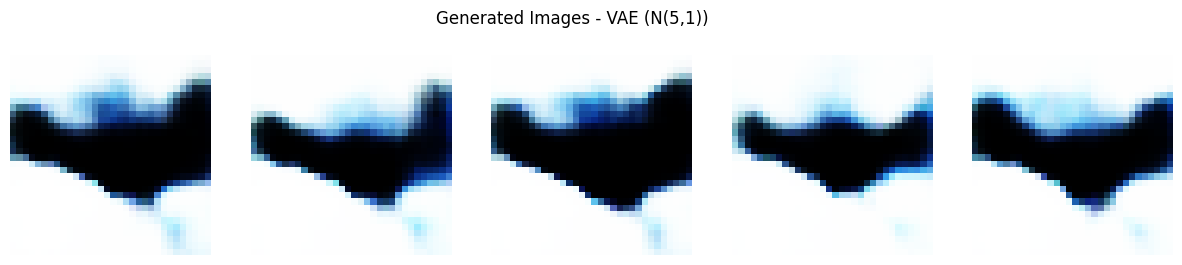

In [43]:
def plot_images(images, title):
    plt.figure(figsize=(15, 3))
    for i in range(5):
        plt.subplot(1, 5, i + 1)
        plt.imshow(images[i])
        plt.axis('off')
    plt.suptitle(title)
    plt.show()

plot_images(generated_images, "Generated Images - VAE (N(5,1))")


## Plot Loss Curves

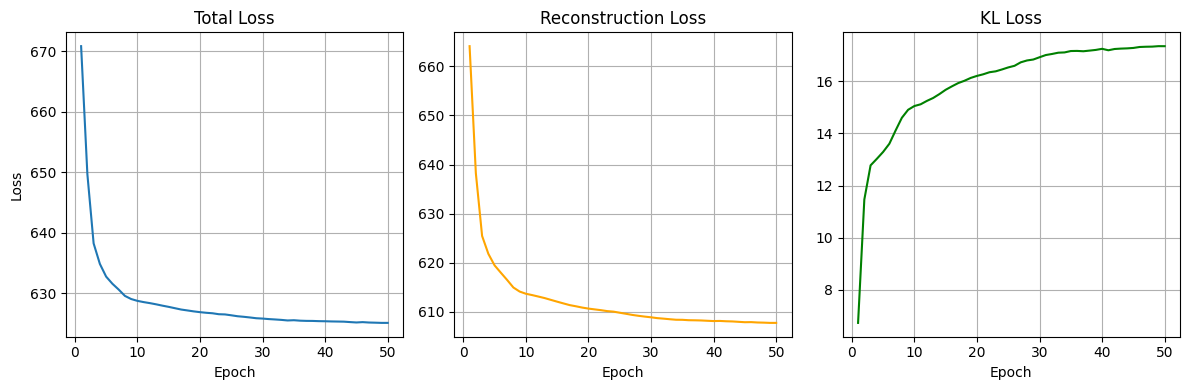

In [38]:
epochs = range(1, len(history_callback.total_losses) + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.plot(epochs, history_callback.total_losses, label='Total Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Total Loss')
plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(epochs, history_callback.reconstruction_losses, label='Reconstruction Loss', color='orange')
plt.xlabel('Epoch')
plt.title('Reconstruction Loss')
plt.grid(True)

plt.subplot(1, 3, 3)
plt.plot(epochs, history_callback.kl_losses, label='KL Divergence', color='green')
plt.xlabel('Epoch')
plt.title('KL Loss')
plt.grid(True)

plt.tight_layout()
plt.show()


## Reconsrtuct some images using test datasets via VAE

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 273ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


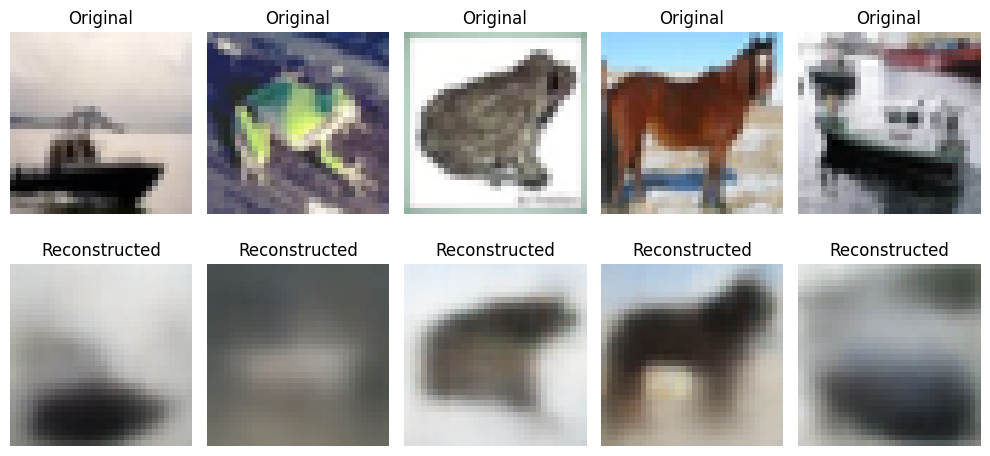

In [39]:
n = 5
(_, _), (x_test, _) = tf.keras.datasets.cifar10.load_data()
x_test = x_test.astype("float32") / 255.0

# Select random test images
random_indices = np.random.randint(0, x_test.shape[0], size=n)
test_images = x_test[random_indices]

# Encode and decode
z_mean, z_log_var = vae.encoder.predict(test_images)
z = vae.sampler([z_mean, z_log_var])
reconstructed_images = vae.decoder.predict(z)

plt.figure(figsize=(10, 5))

# First row: Original images
for i in range(n):
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(test_images[i])
    plt.title("Original")
    plt.axis('off')

# Second row: Reconstructed images
for i in range(n):
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(reconstructed_images[i])
    plt.title("Reconstructed")
    plt.axis('off')

plt.tight_layout()
plt.show()
